# Imputación de valores faltantes y Missing Indicator

Este notebook amplía la idea del archivo base y muestra un ejemplo más extenso con datos tabulares. Veremos cómo crear un dataset con faltantes, explorar el patrón de missingness, aplicar distintas estrategias de imputación y agregar indicadores de faltantes.

## Objetivos

- Entender por qué no siempre conviene imputar igual todas las columnas.
- Comparar `SimpleImputer`, `KNNImputer` y `MissingIndicator`.
- Construir pipelines reproducibles con `ColumnTransformer`.
- Ver cómo cambia un modelo simple cuando agregamos indicadores de faltantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

## 1. Crear un dataset sintético más realista

In [2]:
n = 1200
df = pd.DataFrame({
    'edad': rng.integers(21, 70, size=n),
    'ingreso_mensual': rng.normal(3500, 1200, size=n).clip(700, 12000),
    'deuda_total': rng.normal(9000, 4500, size=n).clip(0, 50000),
    'antiguedad_laboral': rng.normal(6, 4, size=n).clip(0, 35),
    'ciudad': rng.choice(['Bogotá', 'Medellín', 'Cali', 'Barranquilla'], size=n, p=[0.35, 0.30, 0.20, 0.15]),
    'segmento': rng.choice(['Masivo', 'Preferente', 'Pyme'], size=n, p=[0.65, 0.20, 0.15]),
    'canal': rng.choice(['App', 'Web', 'Oficina'], size=n, p=[0.55, 0.30, 0.15])
})

score_latente = (
    -0.00035 * df['ingreso_mensual']
    +0.00008 * df['deuda_total']
    -0.10 * df['antiguedad_laboral']
    +0.015 * df['edad']
    +df['segmento'].map({'Masivo': 0.35, 'Preferente': -0.25, 'Pyme': 0.10})
)

prob_default = 1 / (1 + np.exp(-(score_latente - score_latente.mean())))
df['default'] = rng.binomial(1, prob_default)

df.head()

,edad,ingreso_mensual,deuda_total,antiguedad_laboral,ciudad,segmento,canal,default
0,25,4997.539982,9948.000950,5.499822,Medellín,Masivo,App,1
1,58,3196.979199,3953.560293,3.559605,Barranquilla,Masivo,Oficina,0
2,53,3936.145205,15580.598686,15.198656,Bogotá,Masivo,App,1
3,42,700.000000,12641.376293,5.641077,Cali,Pyme,App,0
4,42,2112.382808,9429.475673,12.180929,Bogotá,Masivo,Web,1


## 2. Introducir valores faltantes con lógica

No todos los faltantes son completamente aleatorios. Vamos a crear algunos patrones donde, por ejemplo, cierto segmento tenga más probabilidad de no reportar ingresos.

In [3]:
mask_ingreso = (df['segmento'] == 'Masivo') & (rng.random(n) < 0.18)
mask_deuda = (df['canal'] == 'App') & (rng.random(n) < 0.12)
mask_ant = rng.random(n) < 0.08
mask_ciudad = rng.random(n) < 0.05
mask_canal = rng.random(n) < 0.03

df_missing = df.copy()
df_missing.loc[mask_ingreso, 'ingreso_mensual'] = np.nan
df_missing.loc[mask_deuda, 'deuda_total'] = np.nan
df_missing.loc[mask_ant, 'antiguedad_laboral'] = np.nan
df_missing.loc[mask_ciudad, 'ciudad'] = np.nan
df_missing.loc[mask_canal, 'canal'] = np.nan

df_missing.isna().mean().sort_values(ascending=False)

ingreso_mensual       0.134167
antiguedad_laboral    0.068333
deuda_total           0.057500
ciudad                0.045000
canal                 0.026667
edad                  0.000000
segmento              0.000000
default               0.000000
dtype: float64

## 3. Explorar patrón de faltantes

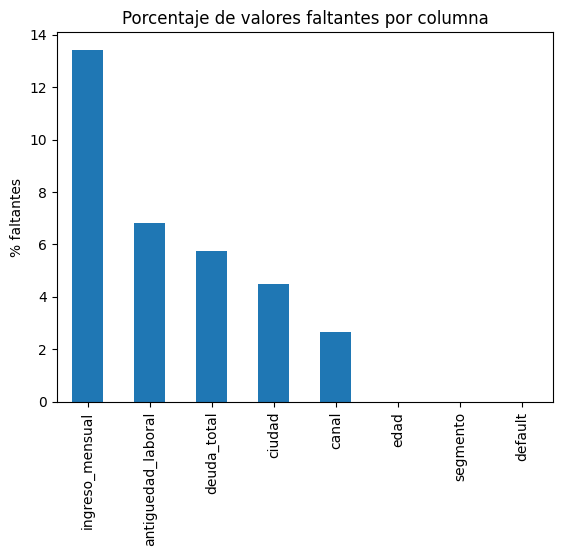

In [4]:
missing_pct = (df_missing.isna().mean() * 100).sort_values(ascending=False)
missing_pct.plot(kind='bar')
plt.title('Porcentaje de valores faltantes por columna')
plt.ylabel('% faltantes')
plt.show()

In [5]:
df_missing.assign(
    ingreso_missing=df_missing['ingreso_mensual'].isna().astype(int),
    deuda_missing=df_missing['deuda_total'].isna().astype(int)
).groupby('segmento')[['ingreso_missing', 'deuda_missing']].mean()

,ingreso_missing,deuda_missing
segmento,,
Masivo,0.206146,0.052497
Preferente,0.000000,0.064257
Pyme,0.000000,0.070588


## 4. Separar variables

In [16]:
X = df_missing.drop(columns='default')
y = df_missing['default']

num_cols = ['edad', 'ingreso_mensual', 'deuda_total', 'antiguedad_laboral']
cat_cols = ['ciudad', 'segmento', 'canal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((900, 7), (300, 7))

## 5. SimpleImputer: estrategia distinta por tipo de dato

In [9]:
numeric_simple = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

model_simple.fit(X_train, y_train)
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [7]:
numeric_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

model_simple.fit(X_train, y_train)
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

AUC simple imputer: 0.6541


## 6. KNNImputer para numéricas + imputación clásica para categóricas

KNN suele ser más costoso, pero puede capturar mejor la relación entre variables numéricas.

In [10]:
numeric_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', StandardScaler())
])

categorical_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_knn = ColumnTransformer(transformers=[
    ('num', numeric_knn, num_cols),
    ('cat', categorical_knn, cat_cols)
])

model_knn = Pipeline(steps=[
    ('prep', preprocess_knn),
    ('clf', LogisticRegression(max_iter=2000))
])

model_knn.fit(X_train, y_train)
pred_proba_knn = model_knn.predict_proba(X_test)[:, 1]
print('AUC KNN imputer:', round(roc_auc_score(y_test, pred_proba_knn), 4))

AUC KNN imputer: 0.6451


## 7. MissingIndicator

A veces el hecho de que falte un dato es informativo. Por ejemplo, no reportar ingresos puede correlacionarse con mayor riesgo.

In [11]:
indicator = MissingIndicator(features='missing-only')
indicator.fit(X_train[num_cols + cat_cols])
indicator_features = indicator.features_
indicator_features

array([1, 2, 3, 4, 6])

In [12]:
numeric_with_ind = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_with_ind = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_with_ind = ColumnTransformer(transformers=[
    ('num', numeric_with_ind, num_cols),
    ('cat', categorical_with_ind, cat_cols),
    ('miss', MissingIndicator(features='missing-only'), num_cols + cat_cols)
])

model_with_ind = Pipeline(steps=[
    ('prep', preprocess_with_ind),
    ('clf', LogisticRegression(max_iter=2000))
])

model_with_ind.fit(X_train, y_train)
pred_proba_with_ind = model_with_ind.predict_proba(X_test)[:, 1]
print('AUC con missing indicators:', round(roc_auc_score(y_test, pred_proba_with_ind), 4))

AUC con missing indicators: 0.6594


## 8. Comparación rápida

In [13]:
results = pd.DataFrame({
    'estrategia': ['SimpleImputer', 'KNNImputer', 'SimpleImputer + MissingIndicator'],
    'auc_test': [
        roc_auc_score(y_test, pred_proba_simple),
        roc_auc_score(y_test, pred_proba_knn),
        roc_auc_score(y_test, pred_proba_with_ind)
    ]
}).sort_values('auc_test', ascending=False)
results

,estrategia,auc_test
2,SimpleImputer + MissingIndicator,0.659406
0,SimpleImputer,0.654116
1,KNNImputer,0.645137


## 9. Ver ejemplos concretos de imputación

In [14]:
sample_rows = X_train.loc[X_train[num_cols + cat_cols].isna().any(axis=1)].head(8).copy()
sample_rows

,edad,ingreso_mensual,deuda_total,antiguedad_laboral,ciudad,segmento,canal
657,52,NaN,7908.214287,5.314201,Bogotá,Masivo,Web
35,24,1791.518678,10232.117304,4.315388,Cali,Masivo,NaN
643,44,NaN,NaN,7.313096,NaN,Masivo,App
1160,49,3272.533386,15397.321401,NaN,Cali,Masivo,App
617,34,NaN,5006.412789,4.493621,Bogotá,Masivo,App
988,33,2738.224203,NaN,2.783400,Medellín,Masivo,App
1186,27,NaN,5686.770976,0.618116,Bogotá,Masivo,App
658,24,NaN,4688.947797,0.837014,Medellín,Masivo,App


In [15]:
simple_num_imputer = SimpleImputer(strategy='median')
simple_num_imputer.fit(X_train[num_cols])
sample_num_imputed = pd.DataFrame(
    simple_num_imputer.transform(sample_rows[num_cols]),
    columns=num_cols,
    index=sample_rows.index
)
pd.concat([sample_rows[num_cols], sample_num_imputed.add_suffix('_imputado')], axis=1)

,edad,ingreso_mensual,deuda_total,antiguedad_laboral,edad_imputado,ingreso_mensual_imputado,deuda_total_imputado,antiguedad_laboral_imputado
657,52,NaN,7908.214287,5.314201,52.0,3472.119547,7908.214287,5.314201
35,24,1791.518678,10232.117304,4.315388,24.0,1791.518678,10232.117304,4.315388
643,44,NaN,NaN,7.313096,44.0,3472.119547,9145.665453,7.313096
1160,49,3272.533386,15397.321401,NaN,49.0,3272.533386,15397.321401,6.041342
617,34,NaN,5006.412789,4.493621,34.0,3472.119547,5006.412789,4.493621
988,33,2738.224203,NaN,2.783400,33.0,2738.224203,9145.665453,2.783400
1186,27,NaN,5686.770976,0.618116,27.0,3472.119547,5686.770976,0.618116
658,24,NaN,4688.947797,0.837014,24.0,3472.119547,4688.947797,0.837014


## 10. Conclusiones

- No hay una estrategia universal de imputación.
- Para numéricas, mediana suele ser un baseline muy fuerte.
- KNN puede mejorar, pero es más lento y sensible a escala.
- Los missing indicators son útiles cuando el faltante tiene señal propia.
- Lo mejor es validar en un pipeline y comparar métricas.